<a href="https://colab.research.google.com/github/DammuNikhitha/AI-ML-Internship-Task-8/blob/main/01_TASK8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**TASK 8: Decision Tree – Bank Marketing Subscription Prediction**

#Step 1: Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

#Step 2: Load Dataset

In [2]:
df = pd.read_csv('/content/bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


#Step 3: Explore Dataset
##1. Check data types

##2. Target Feature
y – Indicates whether the customer subscribed to a term deposit

- yes → Subscribed
- no → Not Subscribed

In [3]:
df.info()
df['y'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,count
y,
no,39922
yes,5289


#Step 4: Handle Missing / Unknown Values

In [4]:
df.replace('unknown', pd.NA, inplace=True)
df.fillna('missing', inplace=True)

#Step 5: Encode Categorical Features
- One-Hot Encoding for categorical features

In [5]:
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

X = pd.get_dummies(X, drop_first=True)

#Step 6: Train-Test Split
- Split dataset using fixed random_state

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Step 7: Train Decision Tree Classifier
- Use Gini Impurity
- Limit max_depth

In [7]:
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

#Step 8: Model Evaluation
- Training Accuracy
- Testing Accuracy

In [8]:
train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9065748728157488
Test Accuracy: 0.8973791883224593


#Step 9: Classification Report

In [9]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7952
           1       0.65      0.33      0.44      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



#Step 10: Visualize Decision Tree
- Visualize splits using plot_tree()

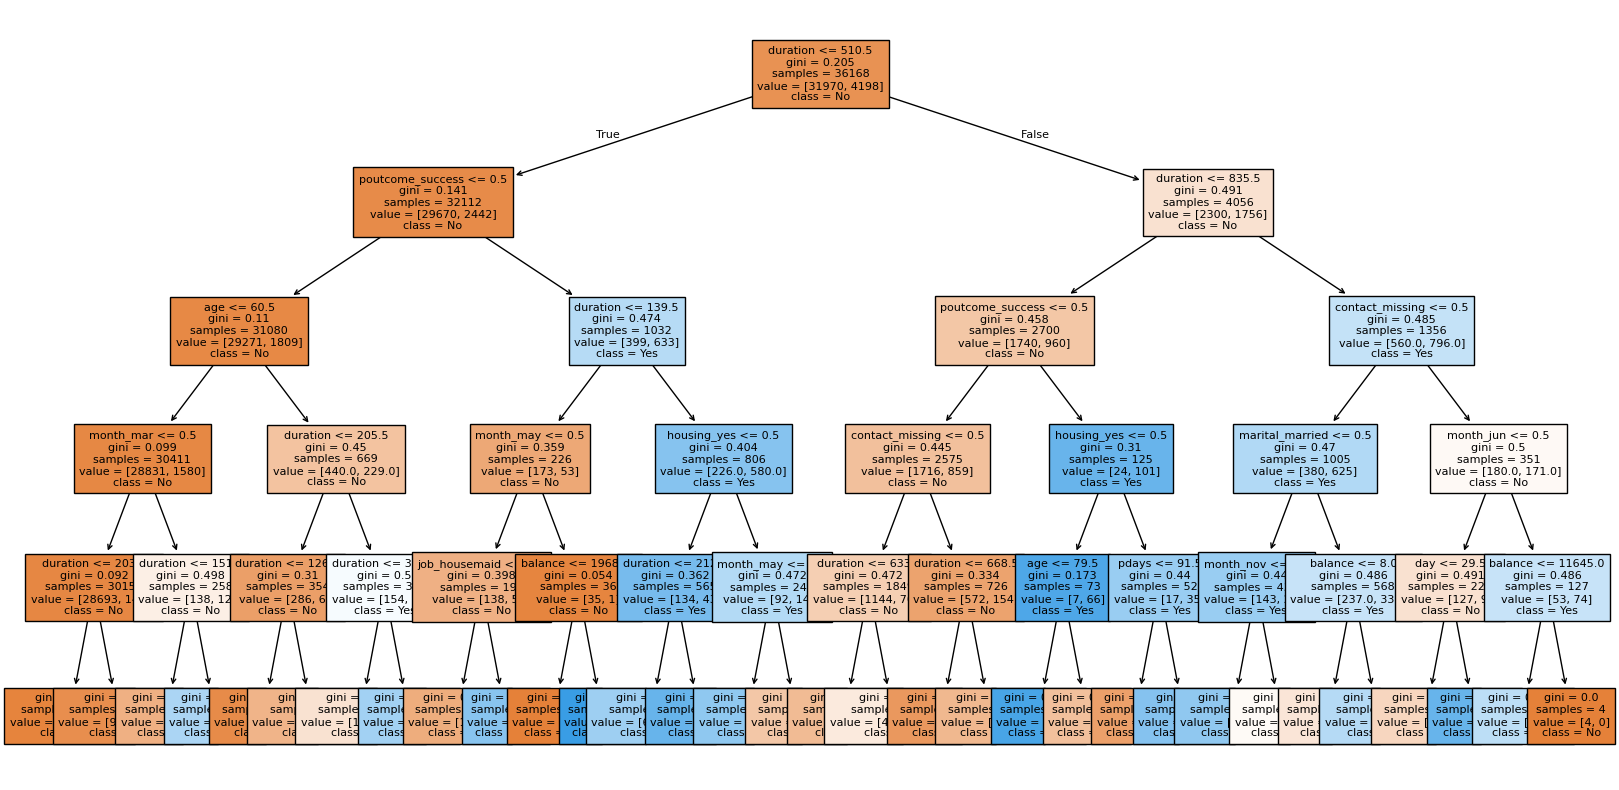

In [10]:
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    fontsize=8
)
plt.show()

#Step 11: Overfitting Check
- If train accuracy > test accuracy, model may be overfitting

- Limiting max_depth helps control overfitting

#Step 12: Key Decision Rules (Example)

1. If previous campaign outcome is successful, customer is likely to subscribe.
2. Customers contacted for longer duration calls are more likely to subscribe.
3. Fewer campaign contacts increase the probability of subscription.